### module 1: Data Collection


In [43]:
import pandas as pd
df = pd.read_csv(r'C:\Users\revat\Downloads\FWI Dataset.csv')
print("dataset loaded successfully")

dataset loaded successfully


In [44]:
df = df.dropna(how='all')
header_rows = df[df['day'] == 'day'].index
text_rows = df[df['day'].astype(str).str.contains("sidi", case=False, na=False)].index
bad_rows = header_rows.union(text_rows)
if len(header_rows) > 0:
    split_index = header_rows[0]  
    df = df.drop(bad_rows)
    df['region'] = "Bejaia"
    df.loc[df.index > split_index, 'region'] = "Sidi-Bel Abbes"
else:
    df['region'] = "Bejaia"
df = df.reset_index(drop=True)
df.to_csv("FWI_Dataset_cleaned.csv", index=False)
cleaned_df = pd.read_csv("FWI_Dataset_cleaned.csv")

print(cleaned_df.head(10))
print(cleaned_df.tail(10))


   day  month  year  Temperature   RH   Ws  Rain   FFMC   DMC    DC  ISI  \
0    1      6  2012           29   57   18    0.0  65.7   3.4   7.6  1.3   
1    2      6  2012           29   61   13    1.3  64.4   4.1   7.6  1.0   
2    3      6  2012           26   82   22   13.1  47.1   2.5   7.1  0.3   
3    4      6  2012           25   89   13    2.5  28.6   1.3   6.9  0.0   
4    5      6  2012           27   77   16    0.0  64.8   3.0  14.2  1.2   
5    6      6  2012           31   67   14    0.0  82.6   5.8  22.2  3.1   
6    7      6  2012           33   54   13    0.0  88.2   9.9  30.5  6.4   
7    8      6  2012           30   73   15    0.0  86.6  12.1  38.3  5.6   
8    9      6  2012           25   88   13    0.2  52.9   7.9  38.8  0.4   
9   10      6  2012           28   79   12    0.0  73.2   9.5  46.3  1.3   

    BUI  FWI    Classes    region  
0   3.4  0.5  not fire     Bejaia  
1   3.9  0.4  not fire     Bejaia  
2   2.7  0.1  not fire     Bejaia  
3   1.7    0  not f

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          244 non-null    object
 1   month        244 non-null    object
 2   year         244 non-null    object
 3   Temperature  244 non-null    object
 4    RH          244 non-null    object
 5    Ws          244 non-null    object
 6   Rain         244 non-null    object
 7   FFMC         244 non-null    object
 8   DMC          244 non-null    object
 9   DC           244 non-null    object
 10  ISI          244 non-null    object
 11  BUI          244 non-null    object
 12  FWI          244 non-null    object
 13  Classes      243 non-null    object
 14  region       244 non-null    object
dtypes: object(15)
memory usage: 28.7+ KB


In [46]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
file_path=r"C:\FWI project\FWI_Dataset_cleaned.csv"
df=pd.read_csv(file_path)
df.head()


,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,Bejaia
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,Bejaia
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,Bejaia
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,not fire,Bejaia
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,Bejaia


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          244 non-null    int64  
 1   month        244 non-null    int64  
 2   year         244 non-null    int64  
 3   Temperature  244 non-null    int64  
 4    RH          244 non-null    int64  
 5    Ws          244 non-null    int64  
 6   Rain         244 non-null    float64
 7   FFMC         244 non-null    float64
 8   DMC          244 non-null    float64
 9   DC           244 non-null    object 
 10  ISI          244 non-null    float64
 11  BUI          244 non-null    float64
 12  FWI          244 non-null    object 
 13  Classes      243 non-null    object 
 14  region       244 non-null    object 
dtypes: float64(5), int64(6), object(4)
memory usage: 28.7+ KB


In [48]:
df.columns = df.columns.str.strip()


In [49]:
df.rename(columns={'region': 'Region'}, inplace=True)


In [50]:

df['DC'] = pd.to_numeric(df['DC'], errors='coerce')
df['FWI'] = pd.to_numeric(df['FWI'], errors='coerce')
print(df.dtypes)
print(df[['DC','FWI']].isnull().sum())


day              int64
month            int64
year             int64
Temperature      int64
RH               int64
Ws               int64
Rain           float64
FFMC           float64
DMC            float64
DC             float64
ISI            float64
BUI            float64
FWI            float64
Classes         object
Region          object
dtype: object
DC     1
FWI    1
dtype: int64


In [51]:
print(df[['DC','FWI']].head(10))


     DC  FWI
0   7.6  0.5
1   7.6  0.4
2   7.1  0.1
3   6.9  0.0
4  14.2  0.5
5  22.2  2.5
6  30.5  7.2
7  38.3  7.1
8  38.8  0.3
9  46.3  0.9


In [52]:
df['Classes'].fillna(method='ffill', inplace=True)
df.dropna(inplace=True)


In [53]:
df.reset_index(drop=True, inplace=True)


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
 14  Region       243 non-null    object 
dtypes: float64(7), int64(6), object(2)
memory usage: 28.6+ KB


In [55]:

df.drop(columns=['Classes'], inplace=True)
print(df.columns)

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Region'],
      dtype='object')


In [56]:
print(df.isnull().sum())


day            0
month          0
year           0
Temperature    0
RH             0
Ws             0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Region         0
dtype: int64


### module 2:Data EXploration and preprocessing

In [57]:
print(df.columns.tolist())


['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Region']


In [58]:

numeric_cols = ['Temperature', 'RH', 'Ws', 'Rain', 
                'FFMC', 'DMC', 'ISI', 'BUI', 'DC', 'FWI']



In [59]:
outliers = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outlier_rows = df[(df[col] < lower) | (df[col] > upper)]
    outliers[col] = outlier_rows.shape[0]   
    
    print(f"{col}: {outliers[col]} outliers detected")


Temperature: 2 outliers detected
RH: 0 outliers detected
Ws: 8 outliers detected
Rain: 35 outliers detected
FFMC: 13 outliers detected
DMC: 12 outliers detected
ISI: 4 outliers detected
BUI: 11 outliers detected
DC: 14 outliers detected
FWI: 4 outliers detected


Temperature: 2 outliers detected
RH: 0 outliers detected
Ws: 8 outliers detected
Rain: 35 outliers detected
FFMC: 13 outliers detected
DMC: 12 outliers detected
ISI: 4 outliers detected
BUI: 11 outliers detected
DC: 14 outliers detected
FWI: 4 outliers detected


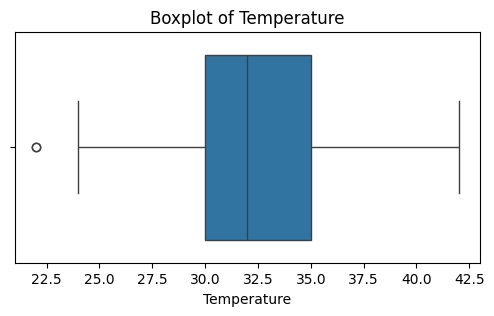

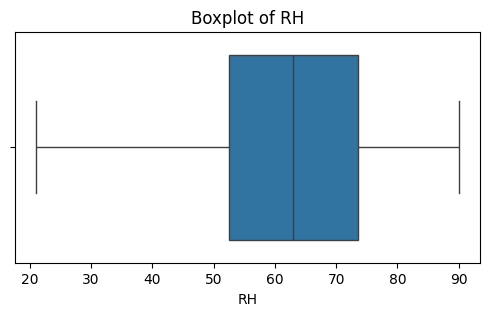

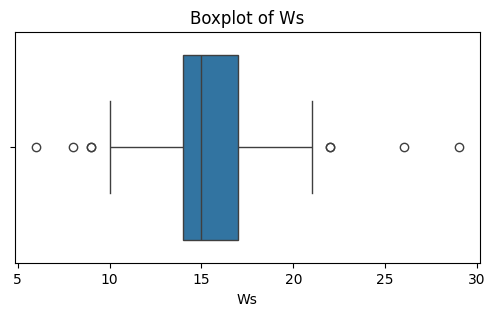

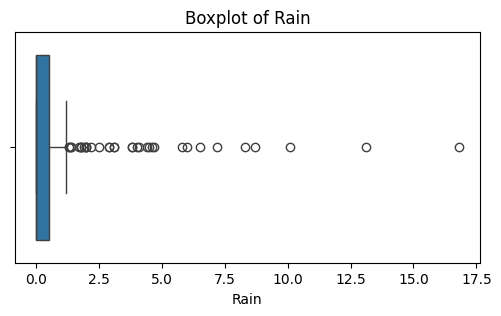

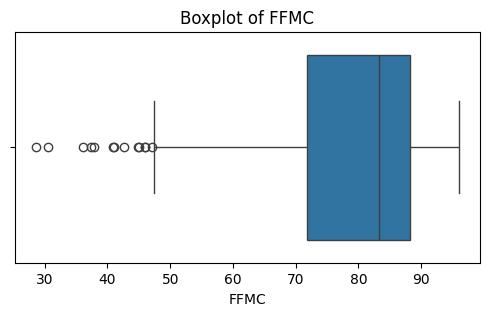

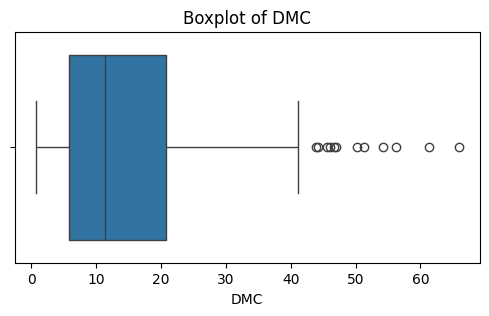

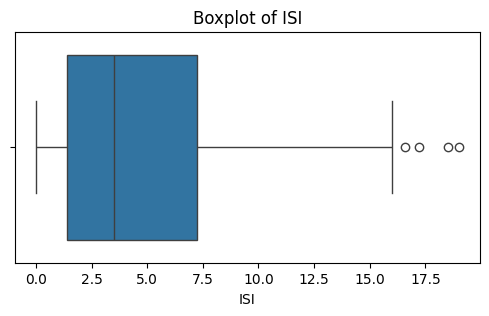

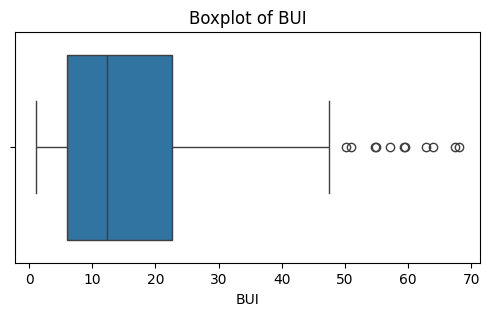

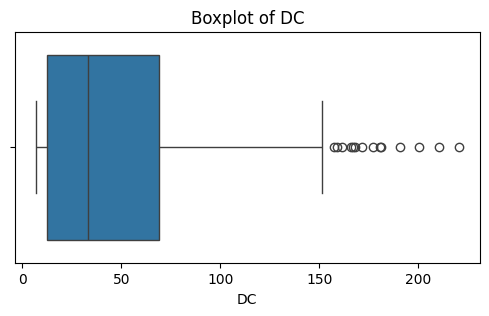

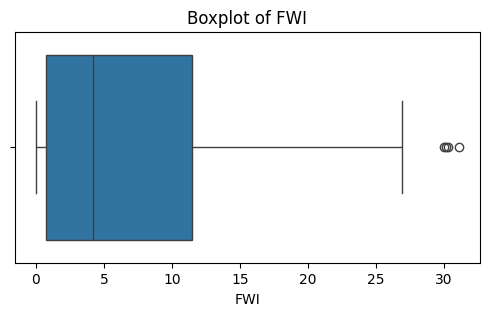

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

outliers = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outlier_rows = df[(df[col] < lower) | (df[col] > upper)]
    outliers[col] = outlier_rows.shape[0]
    print(f"{col}: {outliers[col]} outliers detected")

for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


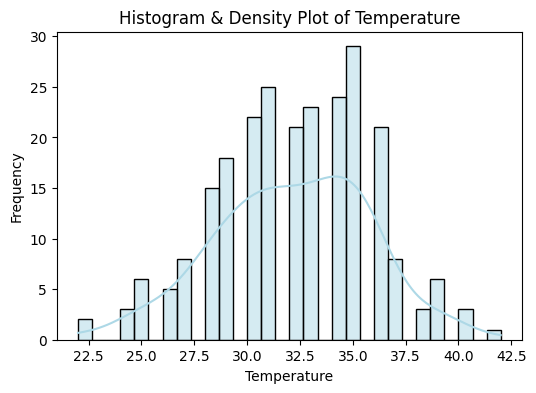

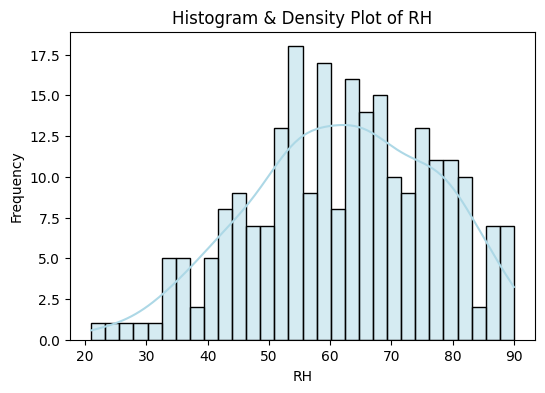

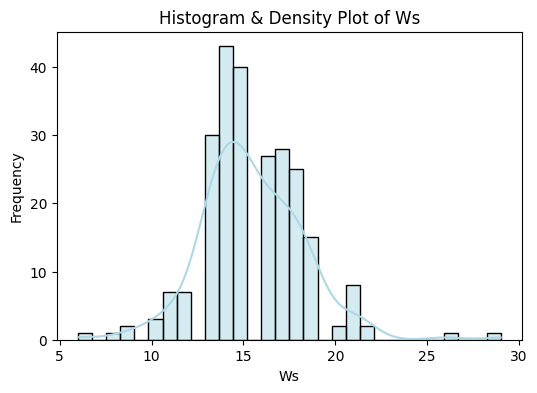

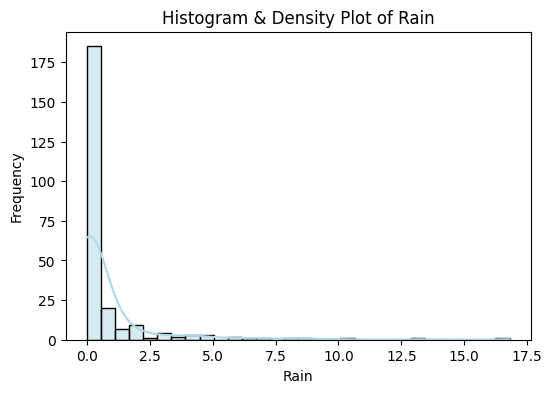

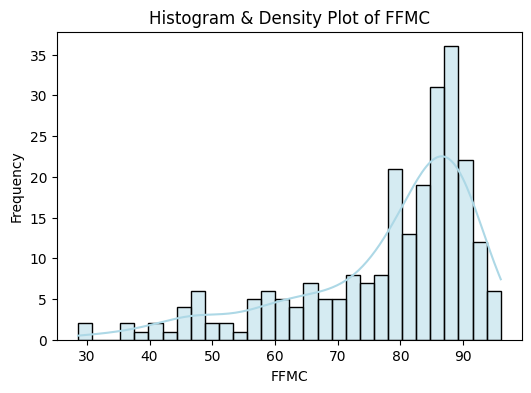

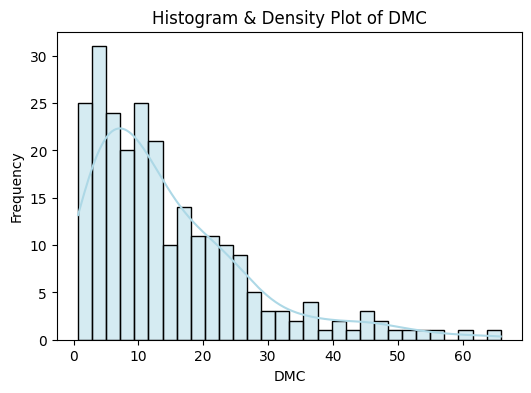

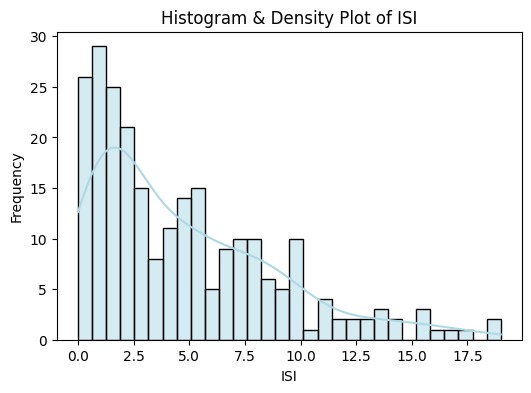

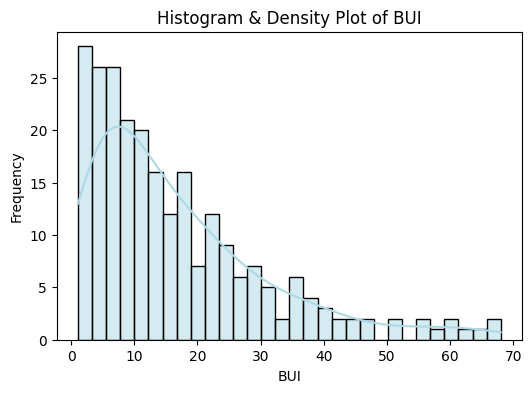

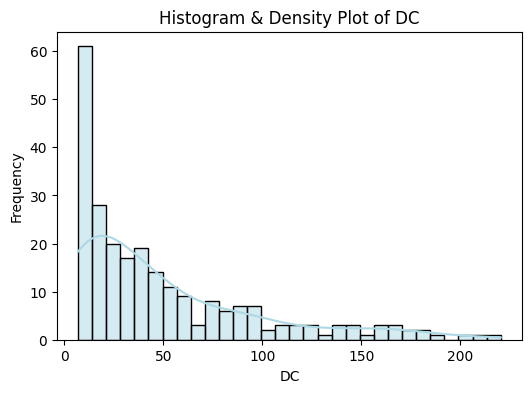

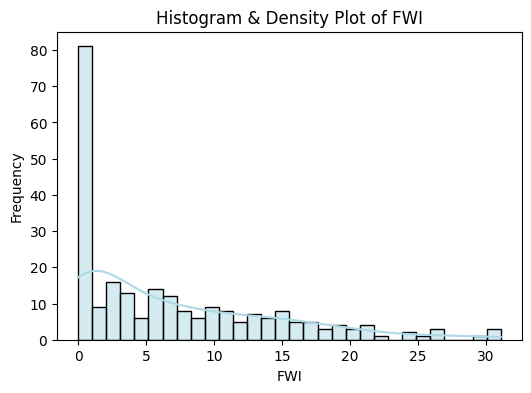

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=30, kde=True, color='lightblue')
    plt.title(f"Histogram & Density Plot of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


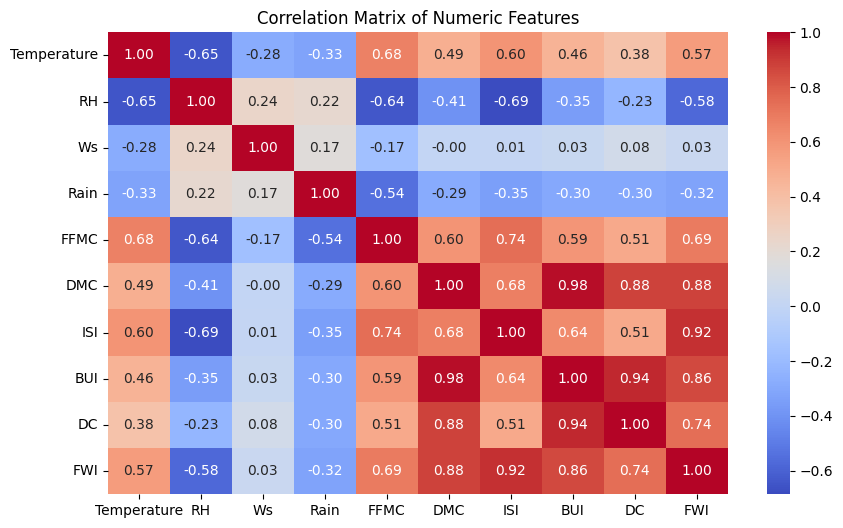

In [62]:
plt.figure(figsize=(10,6))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numeric Features")
plt.show()


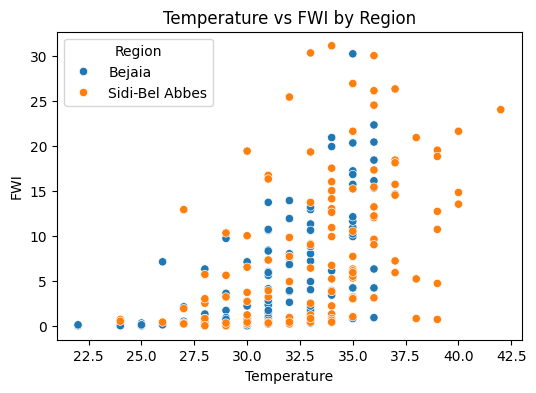

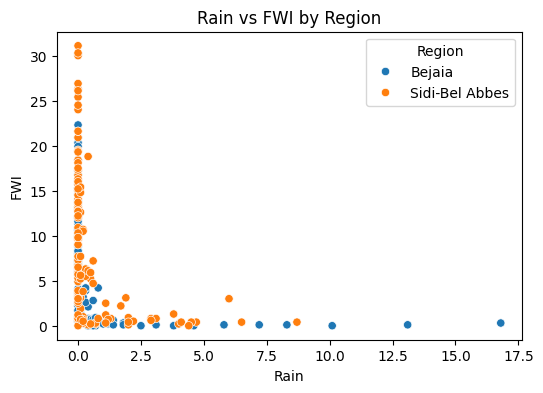

In [63]:
# Example: Temperature vs FWI
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["Temperature"], y=df["FWI"], hue=df["Region"])
plt.title("Temperature vs FWI by Region")
plt.show()

# Example: Rain vs FWI
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["Rain"], y=df["FWI"], hue=df["Region"])
plt.title("Rain vs FWI by Region")
plt.show()


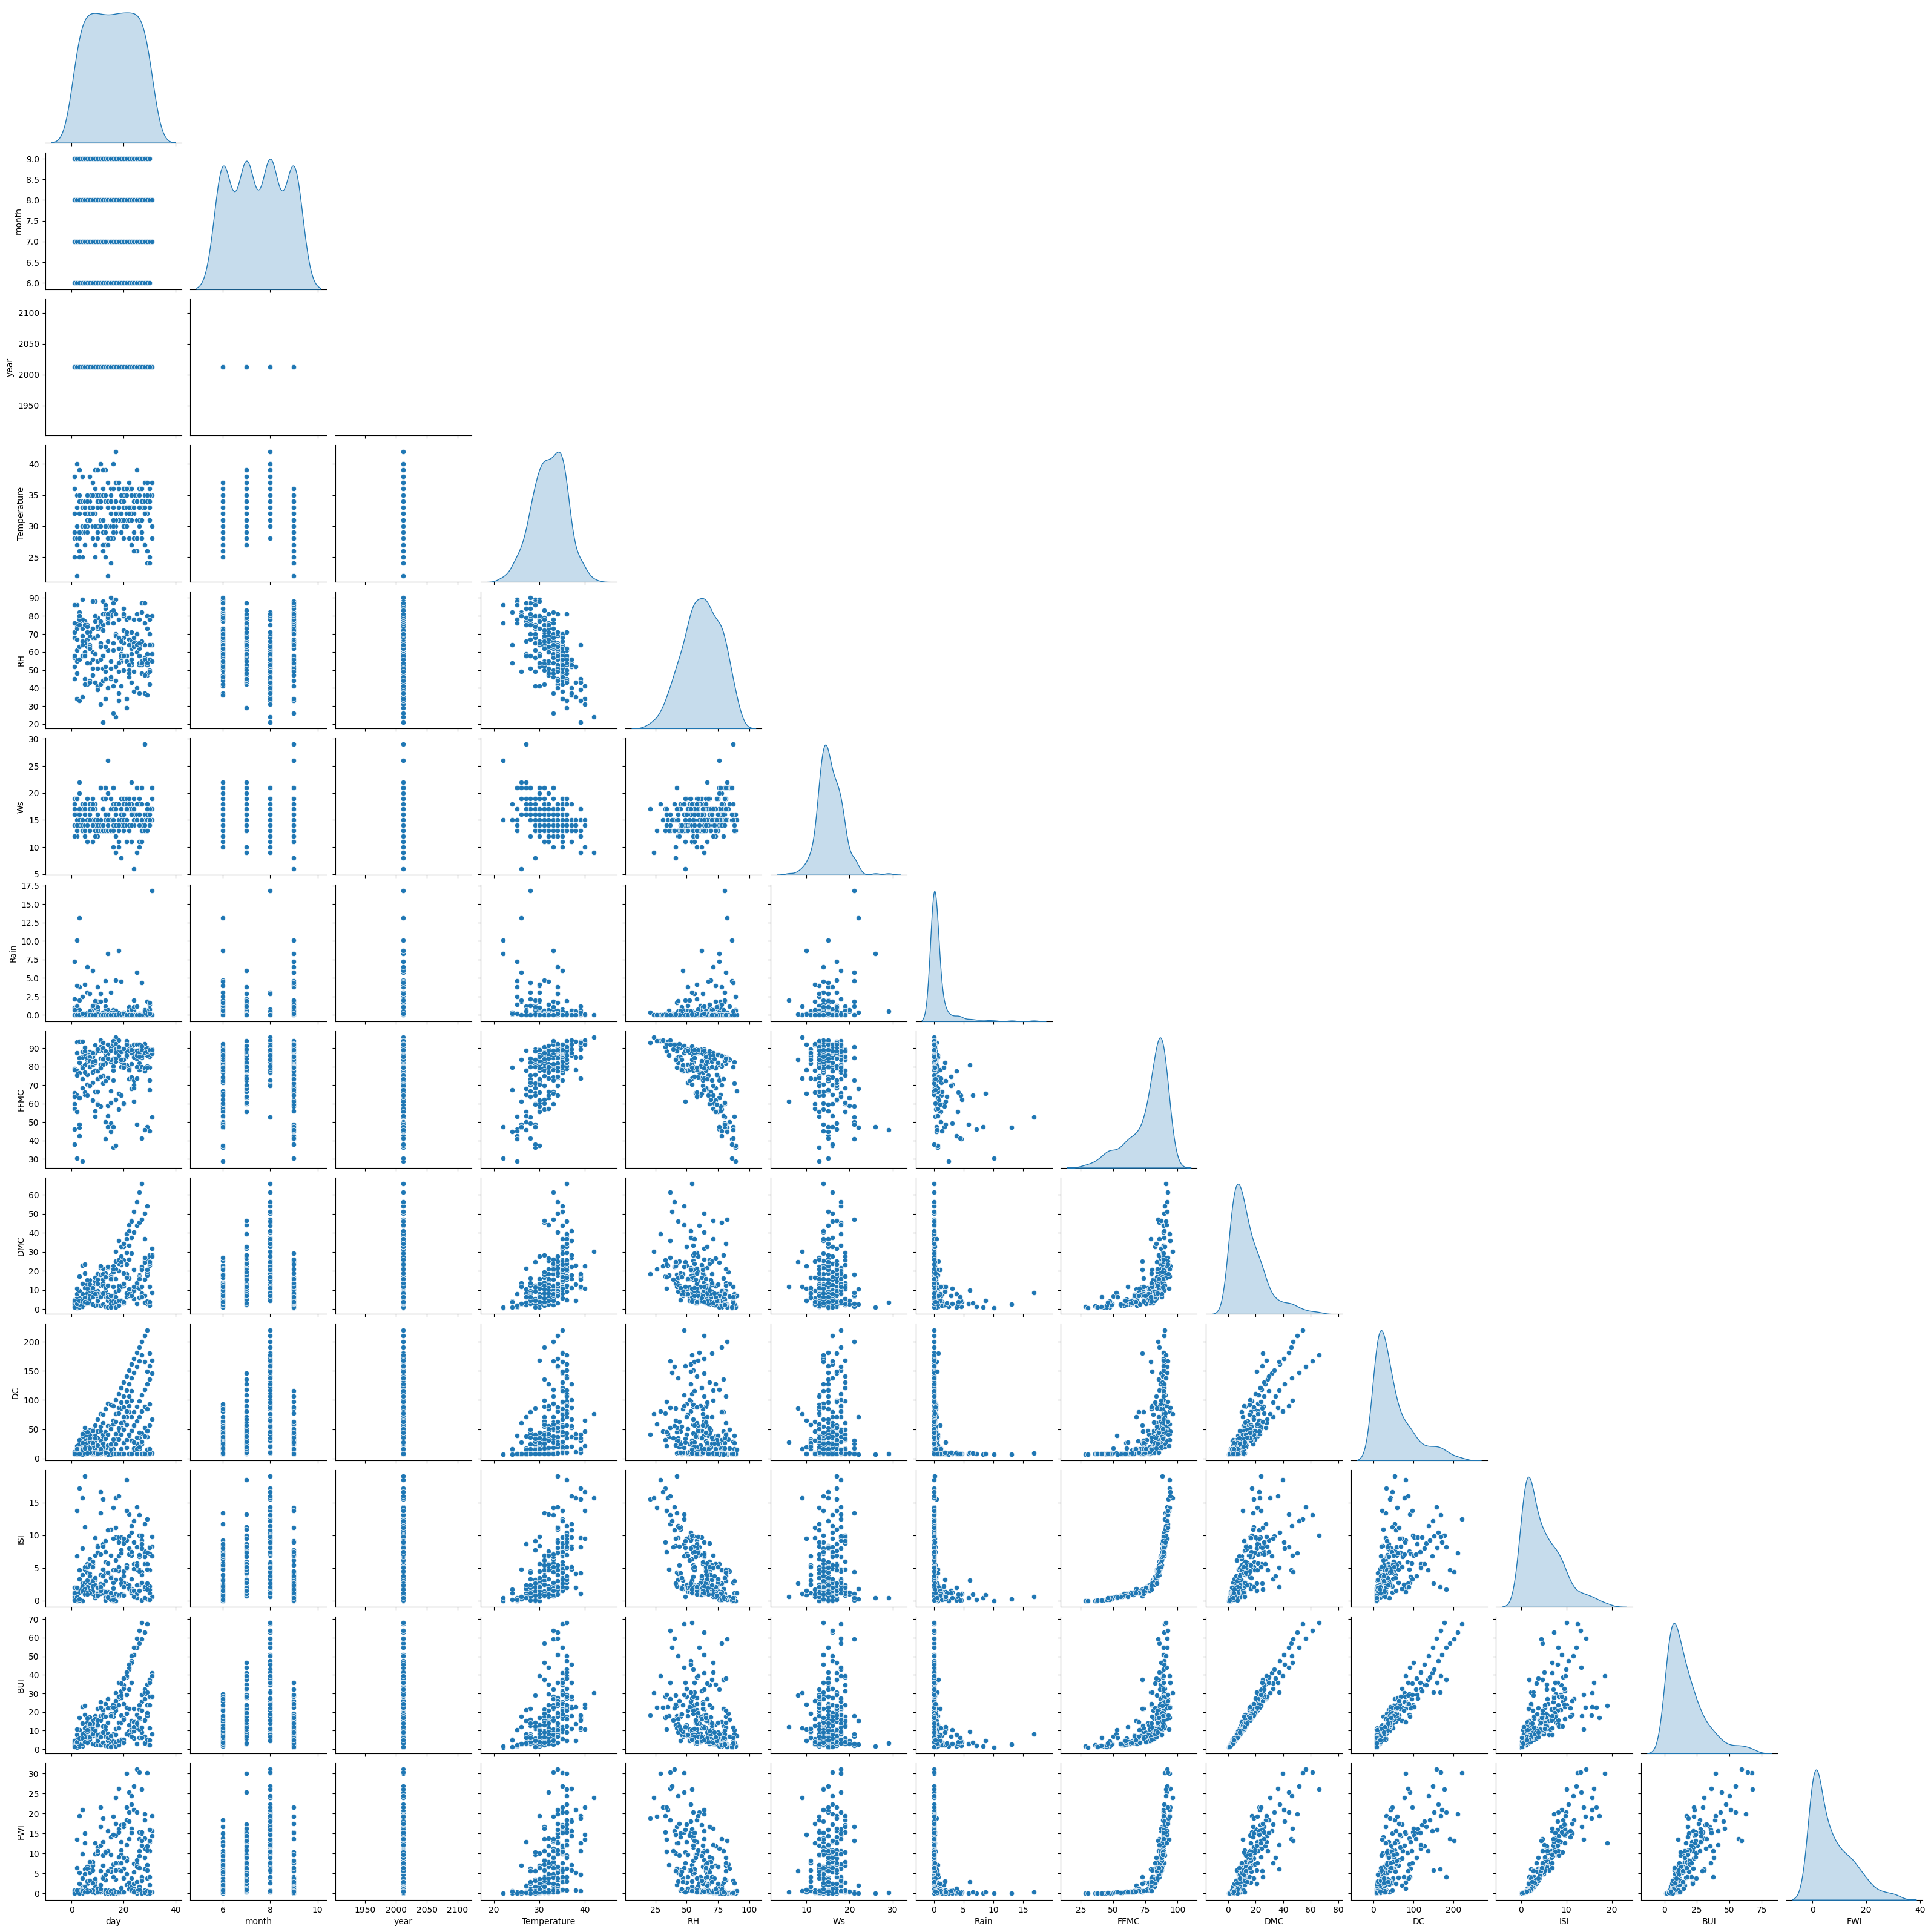

In [64]:
import seaborn as sns 
import matplotlib.pyplot as plt
sns.pairplot(df, diag_kind="kde", corner=True)
plt.show()



In [65]:
print(df['Region'].unique())
print(df['Region'].head(10))
print(df['Region'].dtype)


['Bejaia' 'Sidi-Bel Abbes']
0    Bejaia
1    Bejaia
2    Bejaia
3    Bejaia
4    Bejaia
5    Bejaia
6    Bejaia
7    Bejaia
8    Bejaia
9    Bejaia
Name: Region, dtype: object
object


In [66]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
region_map = {0: "Bejaia", 1: "Sidi-Bel Abbes"}
df['Region'] = df['Region'].map(region_map)

print("Restored Region column (text):")
print(df['Region'].unique())
print(df.head())
le = LabelEncoder()
df['Region'] = le.fit_transform(df['Region'])

print("\nRegion mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
print(df.head())


Restored Region column (text):
[nan]
   day  month  year  Temperature  RH  Ws  Rain  FFMC  DMC    DC  ISI  BUI  \
0    1      6  2012           29  57  18   0.0  65.7  3.4   7.6  1.3  3.4   
1    2      6  2012           29  61  13   1.3  64.4  4.1   7.6  1.0  3.9   
2    3      6  2012           26  82  22  13.1  47.1  2.5   7.1  0.3  2.7   
3    4      6  2012           25  89  13   2.5  28.6  1.3   6.9  0.0  1.7   
4    5      6  2012           27  77  16   0.0  64.8  3.0  14.2  1.2  3.9   

   FWI Region  
0  0.5    NaN  
1  0.4    NaN  
2  0.1    NaN  
3  0.0    NaN  
4  0.5    NaN  

Region mapping: {nan: np.int64(0)}
   day  month  year  Temperature  RH  Ws  Rain  FFMC  DMC    DC  ISI  BUI  \
0    1      6  2012           29  57  18   0.0  65.7  3.4   7.6  1.3  3.4   
1    2      6  2012           29  61  13   1.3  64.4  4.1   7.6  1.0  3.9   
2    3      6  2012           26  82  22  13.1  47.1  2.5   7.1  0.3  2.7   
3    4      6  2012           25  89  13   2.5  28.6  1.3   

In [67]:

df.to_csv("FWI_Dataset_encoded.csv", index=False)

print("Dataset saved successfully as 'FWI_Dataset_encoded.csv'")


Dataset saved successfully as 'FWI_Dataset_encoded.csv'


Module 3:Feature Engineering and Scaling

In [68]:
import pandas as pd
df = pd.read_csv("FWI_Dataset_encoded.csv")
fwi_correlation = df.corr()['FWI'].sort_values(ascending=False)
print("Correlation of features with FWI:\n")
print(fwi_correlation)



Correlation of features with FWI:

FWI            1.000000
ISI            0.922895
DMC            0.875864
BUI            0.857973
DC             0.739521
FFMC           0.691132
Temperature    0.566670
day            0.350781
month          0.082639
Ws             0.032368
Rain          -0.324422
RH            -0.580957
year                NaN
Region              NaN
Name: FWI, dtype: float64


In [69]:

corr_with_target=df.corr()['FWI']
threshold=0.4
key_features = corr_with_target[
    ((abs(corr_with_target) > threshold) | (corr_with_target.index == 'Ws') | (corr_with_target.index == 'Rain')) &
    (corr_with_target.index != 'FWI')   # Exclude target
].index.tolist()

print("Selected features:", key_features)


Selected features: ['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI']


In [70]:
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()
num_cols = df[key_features].select_dtypes(include=['float64', 'int64']).columns
df[num_cols] = standard_scaler.fit_transform(df[num_cols])

print("After scaling, the numerical feature values are:\n")
print(df[num_cols].head())

After scaling, the numerical feature values are:

   Temperature        RH        Ws      Rain      FFMC       DMC        DC  \
0    -0.870655 -0.340673  0.893277 -0.381657 -0.847927 -0.912120 -0.879401   
1    -0.870655 -0.070359 -0.888877  0.268642 -0.938709 -0.855520 -0.879401   
2    -1.699254  1.348788  2.319000  6.171355 -2.146802 -0.984891 -0.889913   
3    -1.975454  1.821837 -0.888877  0.868918 -3.438694 -1.081920 -0.894117   
4    -1.423054  1.010896  0.180416 -0.381657 -0.910776 -0.944463 -0.740651   

        ISI       BUI  
0 -0.830356 -0.936012  
1 -0.902720 -0.900798  
2 -1.071571 -0.985310  
3 -1.143935 -1.055737  
4 -0.854477 -0.900798  


In [71]:

X = df[key_features]
y = df['FWI']
print("Shape of input features (X):", X.shape)
print("Shape of target variable (y):", y.shape)


Shape of input features (X): (243, 9)
Shape of target variable (y): (243,)


In [72]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)


Training set shape: (194, 9) (194,)
Testing set shape: (49, 9) (49,)


In [73]:
import pickle

with open("scaler.pkl", "wb") as f:
    pickle.dump(standard_scaler, f)

print("\nScaler saved successfully as 'scaler.pkl'")




Scaler saved successfully as 'scaler.pkl'


Module 4:Model Training using Ridge Regression

In [74]:
from sklearn.linear_model import Ridge
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

print("Ridge Regression model trained successfully with alpha = 1.0")




Ridge Regression model trained successfully with alpha = 1.0


In [75]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}
grid_search = GridSearchCV(Ridge(), param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)
best_alpha = grid_search.best_params_['alpha']
best_model = grid_search.best_estimator_

print("Best alpha value found:", best_alpha)




Best alpha value found: 10


In [76]:
from sklearn.metrics import r2_score
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
print("Training R² Score:", train_r2)
print("Testing  R² Score:", test_r2)


Training R² Score: 0.9703997471182848
Testing  R² Score: 0.9689736248829521


In [77]:
import pickle
with open('ridge.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Trained Ridge Regression model saved as 'ridge.pkl'.")


Trained Ridge Regression model saved as 'ridge.pkl'.


In [78]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_train_pred = linear_model.predict(X_train)
y_test_pred = linear_model.predict(X_test)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Linear Regression:")
print("Training R² Score:", train_r2)
print("Testing  R² Score:", test_r2)


Linear Regression:
Training R² Score: 0.973083838832041
Testing  R² Score: 0.9882726857720829


In [79]:
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)
y_train_pred = lasso_model.predict(X_train)
y_test_pred = lasso_model.predict(X_test)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\nLasso Regression:")
print("Training R² Score:", train_r2)
print("Testing  R² Score:", test_r2)



Lasso Regression:
Training R² Score: 0.9713894093971112
Testing  R² Score: 0.9824145646094565


In [80]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\nRandom Forest Regressor:")
print("Training R² Score:", train_r2)
print("Testing  R² Score:", test_r2)



Random Forest Regressor:
Training R² Score: 0.9966044379726187
Testing  R² Score: 0.9760910568455469


In [82]:

import numpy as np
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
y_train_pred_lr = linear_model.predict(X_train)
y_test_pred_lr = linear_model.predict(X_test)
train_mae_lr = mean_absolute_error(y_train, y_train_pred_lr)
test_mae_lr = mean_absolute_error(y_test, y_test_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))
r2_lr = r2_score(y_test, y_test_pred_lr)

print("Linear Regression Performance:")
print(f"Train MAE: {train_mae_lr:.4f}")
print(f"Test  MAE: {test_mae_lr:.4f}")
print(f"Test  RMSE: {rmse_lr:.4f}")
print(f"Test  R² Score: {r2_lr:.4f}")


Linear Regression Performance:
Train MAE: 0.6726
Test  MAE: 0.4240
Test  RMSE: 0.5962
Test  R² Score: 0.9883


In [83]:

y_train_pred_lasso = lasso_model.predict(X_train)
y_test_pred_lasso = lasso_model.predict(X_test)
train_mae_lasso = mean_absolute_error(y_train, y_train_pred_lasso)
test_mae_lasso = mean_absolute_error(y_test, y_test_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_test_pred_lasso))
r2_lasso = r2_score(y_test, y_test_pred_lasso)

print("\nLasso Regression Performance:")
print(f"Train MAE: {train_mae_lasso:.4f}")
print(f"Test  MAE: {test_mae_lasso:.4f}")
print(f"Test  RMSE: {rmse_lasso:.4f}")
print(f"Test  R² Score: {r2_lasso:.4f}")



Lasso Regression Performance:
Train MAE: 0.7675
Test  MAE: 0.5446
Test  RMSE: 0.7301
Test  R² Score: 0.9824


In [84]:

y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)
train_mae_rf = mean_absolute_error(y_train, y_train_pred_rf)
test_mae_rf = mean_absolute_error(y_test, y_test_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
r2_rf = r2_score(y_test, y_test_pred_rf)

print("\nRandom Forest Regressor Performance:")
print(f"Train MAE: {train_mae_rf:.4f}")
print(f"Test  MAE: {test_mae_rf:.4f}")
print(f"Test  RMSE: {rmse_rf:.4f}")
print(f"Test  R² Score: {r2_rf:.4f}")



Random Forest Regressor Performance:
Train MAE: 0.2437
Test  MAE: 0.5482
Test  RMSE: 0.8513
Test  R² Score: 0.9761


Module 5: Evaluation and Optimization

In [85]:
from sklearn.metrics import mean_absolute_error
y_pred = best_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error (MAE):", mae)


Mean Absolute Error (MAE): 0.6609842518691338


In [86]:
from sklearn.metrics import mean_squared_error
import numpy as np
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("Root Mean Squared Error (RMSE):", rmse)


Root Mean Squared Error (RMSE): 0.969721843822634


In [87]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.9689736248829521


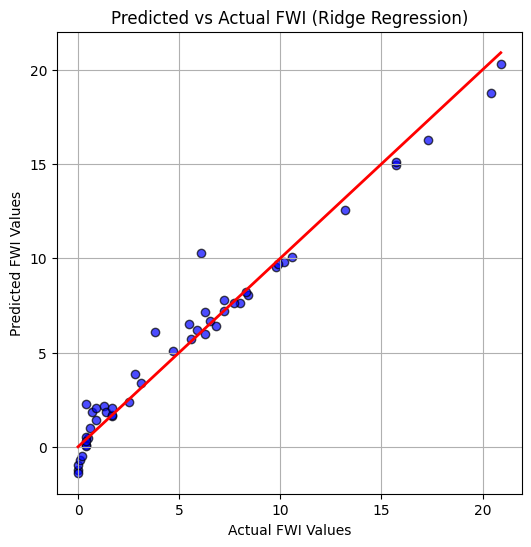

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, color='blue', edgecolor='k', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.xlabel("Actual FWI Values")
plt.ylabel("Predicted FWI Values")
plt.title("Predicted vs Actual FWI (Ridge Regression)")
plt.grid(True)
plt.show()


In [89]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Try alpha values between 0 and 1
alphas = [0.001, 0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 1.0]

print("Ridge Regression Tuning Results :\n")
for a in alphas:
    ridge_new = Ridge(alpha=a)
    ridge_new.fit(X_train, y_train)
    y_pred_test = ridge_new.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2 = r2_score(y_test, y_pred_test)

    print(f"Alpha: {a:<6} | Test R²: {r2:.4f} | MAE: {mae:.4f} | RMSE: {rmse:.4f}")


Ridge Regression Tuning Results :

Alpha: 0.001  | Test R²: 0.9883 | MAE: 0.4242 | RMSE: 0.5966
Alpha: 0.01   | Test R²: 0.9881 | MAE: 0.4260 | RMSE: 0.6000
Alpha: 0.05   | Test R²: 0.9875 | MAE: 0.4324 | RMSE: 0.6160
Alpha: 0.1    | Test R²: 0.9867 | MAE: 0.4390 | RMSE: 0.6346
Alpha: 0.3    | Test R²: 0.9846 | MAE: 0.4539 | RMSE: 0.6839
Alpha: 0.5    | Test R²: 0.9833 | MAE: 0.4621 | RMSE: 0.7107
Alpha: 0.7    | Test R²: 0.9825 | MAE: 0.4678 | RMSE: 0.7279
Alpha: 1.0    | Test R²: 0.9817 | MAE: 0.4748 | RMSE: 0.7457
